---- Performance Analytics

Task 1: Daily Returns Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import linregress

In [ ]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [4]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [5]:
nav.head(15)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


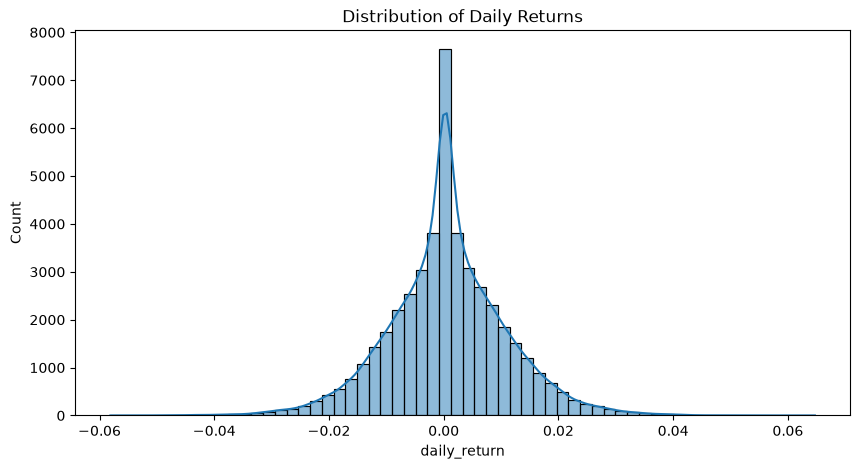

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=60,
    kde=True,
    ax=ax
)

ax.set_title("Distribution of Daily Returns")

fig.savefig(
    "../reports/charts/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
nav.to_csv(
    "../data/processed/daily_returns.csv",
    index=False
)

----  Task 2: CAGR Analysis (1 Year, 3 Year, 5 Year)

In [25]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv")

fund_master = pd.read_csv("../data/processed/clean_01_fund_master.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [26]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [27]:
def calculate_cagr(start_nav, end_nav, years):

    if start_nav <= 0:
        return np.nan

    return ((end_nav / start_nav) ** (1 / years) - 1) * 100

In [28]:
cagr_list = []

for amfi in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == amfi
    ].sort_values("date")

    scheme = fund_master.loc[
        fund_master["amfi_code"] == amfi,
        "scheme_name"
    ].values[0]

    latest_nav = df.iloc[-1]["nav"]

    latest_date = df.iloc[-1]["date"]

    cagr_1 = np.nan
    cagr_3 = np.nan
    cagr_5 = np.nan

    # 1 Year
    df1 = df[df["date"] <= latest_date - pd.DateOffset(years=1)]

    if len(df1) > 0:
        start_nav = df1.iloc[-1]["nav"]
        cagr_1 = calculate_cagr(
            start_nav,
            latest_nav,
            1
        )

    # 3 Year
    df3 = df[df["date"] <= latest_date - pd.DateOffset(years=3)]

    if len(df3) > 0:
        start_nav = df3.iloc[-1]["nav"]
        cagr_3 = calculate_cagr(
            start_nav,
            latest_nav,
            3
        )

    # 5 Year
    df5 = df[df["date"] <= latest_date - pd.DateOffset(years=5)]

    if len(df5) > 0:
        start_nav = df5.iloc[-1]["nav"]
        cagr_5 = calculate_cagr(
            start_nav,
            latest_nav,
            5
        )

    cagr_list.append(
        [
            amfi,
            scheme,
            cagr_1,
            cagr_3,
            cagr_5
        ]
    )

In [29]:
cagr = pd.DataFrame(

    cagr_list,

    columns=[
        "amfi_code",
        "scheme_name",
        "CAGR_1Y",
        "CAGR_3Y",
        "CAGR_5Y"
    ]

)

cagr.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.224271,1.292649,NaN
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.704969,3.916390,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,NaN
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.152381,NaN


In [30]:
cagr.describe()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
count,40.000000,40.000000,40.000000,0.0
mean,120247.000000,19.428520,16.414715,NaN
std,14534.998667,22.912276,12.206752,NaN
min,100016.000000,-42.797615,-11.705807,NaN
25%,118632.750000,7.377949,6.600925,NaN
50%,119551.500000,17.474125,18.233102,NaN
75%,120842.250000,27.161651,26.902600,NaN
max,149324.000000,82.776059,35.111802,NaN


In [31]:
top10 = cagr.sort_values(
    "CAGR_3Y",
    ascending=False
).head(10)

top10

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
16,119094,Axis Midcap Fund - Regular - Growth,22.261065,35.111802,NaN
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,20.360678,34.000916,NaN
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,13.064279,32.487429,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,NaN
25,120505,ICICI Pru Midcap Fund - Regular - Growth,29.604659,31.777537,NaN
19,119551,SBI Bluechip Fund - Regular Plan - Growth,60.437341,30.456524,NaN
30,120843,Kotak Flexicap Fund - Regular - Growth,26.657082,29.582770,NaN
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,39.751761,29.178902,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,NaN
39,149324,DSP Small Cap Fund - Regular - Growth,65.138719,27.000427,NaN


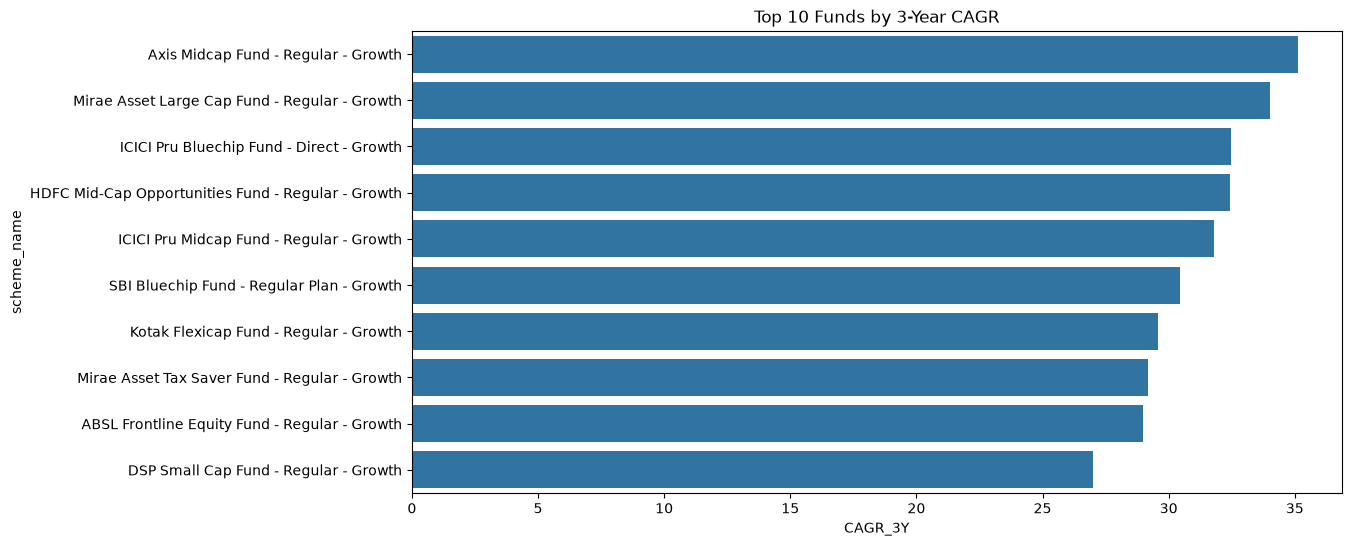

In [32]:
fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(

    data=top10,

    x="CAGR_3Y",

    y="scheme_name",

    ax=ax

)

ax.set_title(
    "Top 10 Funds by 3-Year CAGR"
)

fig.savefig(
    "../reports/charts/top10_cagr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
cagr.to_csv(

    "../data/processed/cagr_comparison.csv",

    index=False

)

---- Task 3: Sharpe Ratio Analysis

In [15]:
daily_returns = pd.read_csv("../data/processed/daily_returns.csv")

daily_returns["date"] = pd.to_datetime(daily_returns["date"])

daily_returns.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [16]:
risk_free_rate = 0.065

daily_rf = risk_free_rate / 252

In [17]:
sharpe_list = []

for amfi in daily_returns["amfi_code"].unique():

    df = daily_returns[
        daily_returns["amfi_code"] == amfi
    ]

    returns = df["daily_return"].dropna()

    if len(returns) == 0:
        continue

    mean_return = returns.mean()

    std_return = returns.std()

    sharpe = (
        (mean_return - daily_rf)
        / std_return
    ) * np.sqrt(252)

    sharpe_list.append(
        [amfi, sharpe]
    )

In [18]:
sharpe = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "Sharpe_Ratio"
    ]
)

sharpe.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [19]:
sharpe = sharpe.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

sharpe.head()

,amfi_code,Sharpe_Ratio,scheme_name
0,100016,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.567095,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.162661,ABSL Small Cap Fund - Regular - Growth


In [20]:
sharpe = sharpe.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe.reset_index(
    drop=True,
    inplace=True
)

sharpe.head(10)

,amfi_code,Sharpe_Ratio,scheme_name
0,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
1,120843,1.306744,Kotak Flexicap Fund - Regular - Growth
2,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
3,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth
4,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth
5,149323,1.132122,DSP Midcap Fund - Regular - Growth
6,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
7,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth
8,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
9,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth


In [21]:
sharpe.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

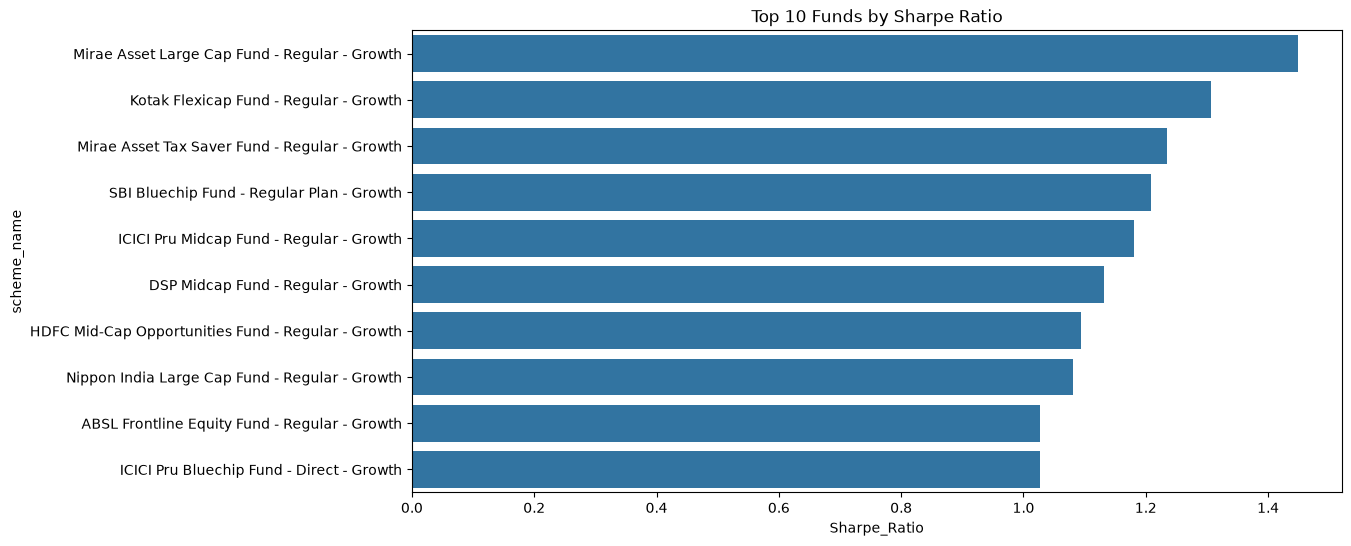

In [22]:
fig, ax = plt.subplots(figsize=(12,6))

top10 = sharpe.head(10)

sns.barplot(
    data=top10,
    x="Sharpe_Ratio",
    y="scheme_name",
    ax=ax
)

ax.set_title("Top 10 Funds by Sharpe Ratio")

fig.savefig(
    "../reports/charts/sharpe_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

----- Sortino Ratio Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

daily_returns = pd.read_csv("../data/processed/daily_returns.csv")

fund_master = pd.read_csv("../data/processed/clean_01_fund_master.csv")

daily_returns.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [2]:
risk_free_rate = 0.065

daily_rf = risk_free_rate / 252

In [3]:
sortino_list = []

for amfi in daily_returns["amfi_code"].unique():

    df = daily_returns[
        daily_returns["amfi_code"] == amfi
    ]

    returns = df["daily_return"].dropna()

    if len(returns) == 0:
        continue

    mean_return = returns.mean()

    downside_returns = returns[
        returns < 0
    ]

    downside_std = downside_returns.std()

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = (
            (mean_return - daily_rf)
            / downside_std
        ) * np.sqrt(252)

    sortino_list.append([
        amfi,
        sortino
    ])

In [4]:
sortino = pd.DataFrame(

    sortino_list,

    columns=[
        "amfi_code",
        "Sortino_Ratio"
    ]

)

sortino.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [5]:
sortino = sortino.merge(

    fund_master[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

sortino.head()

,amfi_code,Sortino_Ratio,scheme_name
0,100016,-0.351047,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.941821,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.276644,ABSL Small Cap Fund - Regular - Growth


In [6]:
sortino.to_csv(

    "../data/processed/sortino_ratio.csv",

    index=False

)

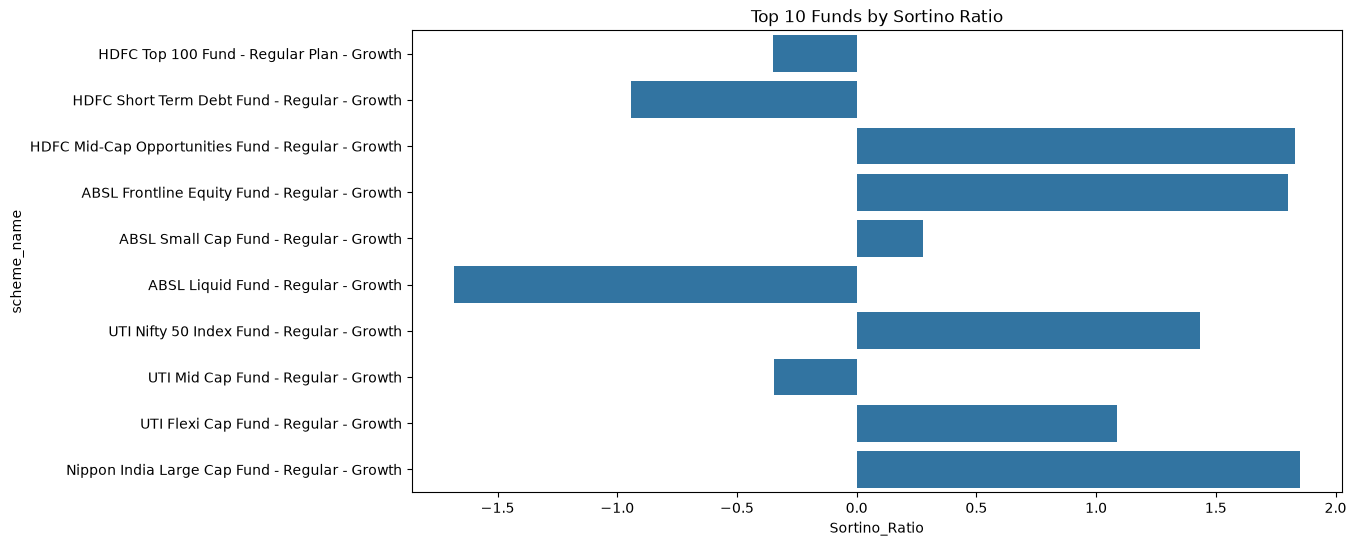

In [7]:
fig, ax = plt.subplots(figsize=(12,6))

top10 = sortino.head(10)

sns.barplot(

    data=top10,

    x="Sortino_Ratio",

    y="scheme_name",

    ax=ax

)

ax.set_title("Top 10 Funds by Sortino Ratio")

fig.savefig(

    "../reports/charts/sortino_ratio.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

------- Alpha & Beta Analysis

In [8]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

In [9]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv")

benchmark = pd.read_csv("../data/processed/clean_10_benchmark_indices.csv")

fund_master = pd.read_csv("../data/processed/clean_01_fund_master.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [10]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [11]:
benchmark.columns.tolist()

['date', 'index_name', 'close_value']

In [12]:
nav.head()
nav.columns.tolist()

['amfi_code', 'date', 'nav']

In [13]:
benchmark = benchmark[
    benchmark["index_name"] == "NIFTY100"
]

In [14]:
benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

benchmark = benchmark[
    ["date", "benchmark_return"]
]

In [15]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["fund_return"] = nav.groupby(
    "amfi_code"
)["nav"].pct_change()

In [16]:
alpha_beta = []

for amfi in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == amfi
    ][
        ["date", "fund_return"]
    ]

    merged = pd.merge(
        fund,
        benchmark,
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r, p, std = linregress(
        merged["benchmark_return"],
        merged["fund_return"]
    )

    beta = slope

    alpha = intercept * 252

    scheme = fund_master.loc[
        fund_master["amfi_code"] == amfi,
        "scheme_name"
    ].values[0]

    alpha_beta.append(
        [
            amfi,
            scheme,
            alpha,
            beta
        ]
    )

In [17]:
alpha_beta = pd.DataFrame(

    alpha_beta,

    columns=[
        "amfi_code",
        "scheme_name",
        "Alpha",
        "Beta"
    ]

)

alpha_beta.head()

,amfi_code,scheme_name,Alpha,Beta
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.037476,-0.058268
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.042818,0.001158
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086
4,101207,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289


In [18]:
alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

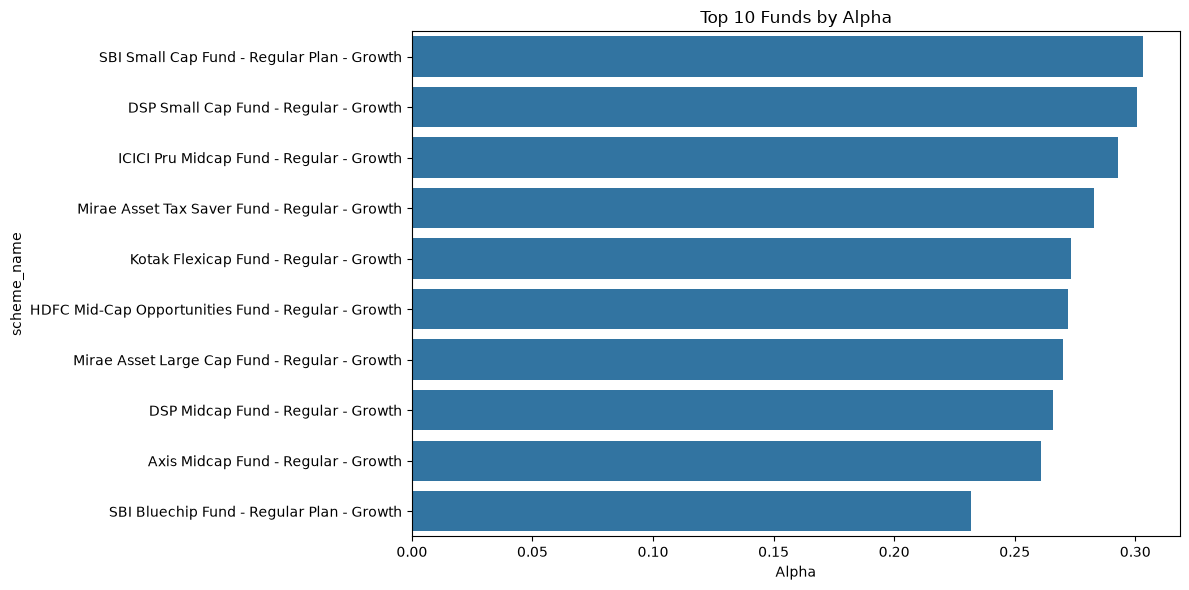

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

top10 = alpha_beta.sort_values(
    "Alpha",
    ascending=False
).head(10)

fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(
    data=top10,
    x="Alpha",
    y="scheme_name",
    ax=ax
)

ax.set_title("Top 10 Funds by Alpha")

plt.tight_layout()

fig.savefig(
    "../reports/charts/alpha_ranking.png",
    dpi=300
)

plt.show()

-----  Maximum Drawdown Analysis

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv("../data/processed/clean_nav_history.csv")

fund_master = pd.read_csv("../data/processed/clean_01_fund_master.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [21]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [22]:
drawdown_list = []

for amfi in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == amfi
    ].copy()

    df = df.sort_values("date")

    df["running_max"] = df["nav"].cummax()

    df["drawdown"] = (
        df["nav"] /
        df["running_max"]
    ) - 1

    max_dd = df["drawdown"].min()

    worst_row = df.loc[
        df["drawdown"].idxmin()
    ]

    scheme = fund_master.loc[
        fund_master["amfi_code"] == amfi,
        "scheme_name"
    ].values[0]

    drawdown_list.append([
        amfi,
        scheme,
        max_dd,
        worst_row["date"]
    ])

In [23]:
drawdown = pd.DataFrame(

    drawdown_list,

    columns=[
        "amfi_code",
        "scheme_name",
        "Maximum_Drawdown",
        "Worst_Date"
    ]

)

drawdown.head()

,amfi_code,scheme_name,Maximum_Drawdown,Worst_Date
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.247344,2022-09-15
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.043083,2023-07-28
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.162172,2022-05-12
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.112916,2023-07-05
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.354469,2026-05-11


In [24]:
drawdown["Maximum_Drawdown"] = (
    drawdown["Maximum_Drawdown"] * 100
)

drawdown.head()

,amfi_code,scheme_name,Maximum_Drawdown,Worst_Date
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-24.734441,2022-09-15
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-4.308264,2023-07-28
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-16.217209,2022-05-12
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-11.291596,2023-07-05
4,101207,ABSL Small Cap Fund - Regular - Growth,-35.446916,2026-05-11


In [25]:
drawdown.to_csv(
    "../data/processed/maximum_drawdown.csv",
    index=False
)

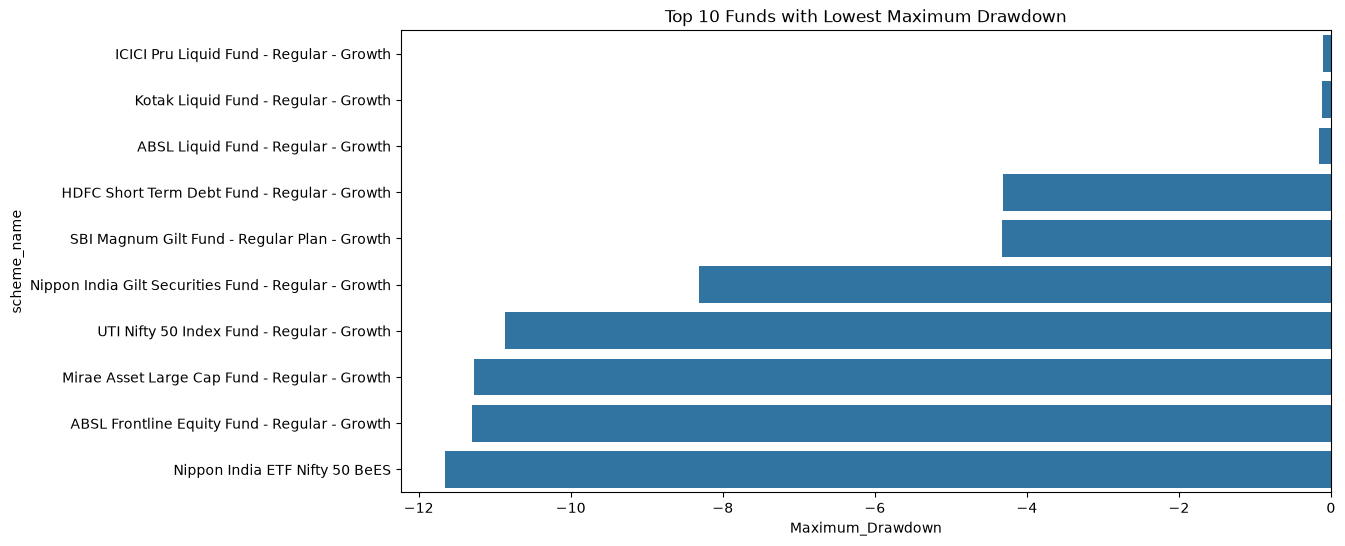

In [26]:
best10 = drawdown.sort_values(
    "Maximum_Drawdown",
    ascending=False
).head(10)

fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(
    data=best10,
    x="Maximum_Drawdown",
    y="scheme_name",
    ax=ax
)

ax.set_title("Top 10 Funds with Lowest Maximum Drawdown")

fig.savefig(
    "../reports/charts/maximum_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
import pandas as pd

nav = pd.read_csv("../data/processed/clean_nav_history.csv")
fund_master = pd.read_csv("../data/processed/clean_01_fund_master.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

drawdown_range = []

for amfi in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == amfi].copy()

    df["running_max"] = df["nav"].cummax()

    df["drawdown"] = (df["nav"] / df["running_max"]) - 1

    # Trough (worst drawdown)
    trough_idx = df["drawdown"].idxmin()
    trough_date = df.loc[trough_idx, "date"]

    # Peak before trough
    peak_idx = df.loc[:trough_idx, "nav"].idxmax()
    peak_date = df.loc[peak_idx, "date"]

    max_drawdown = df.loc[trough_idx, "drawdown"] * 100

    scheme = fund_master.loc[
        fund_master["amfi_code"] == amfi,
        "scheme_name"
    ].values[0]

    drawdown_range.append([
        amfi,
        scheme,
        peak_date,
        trough_date,
        round(max_drawdown, 2)
    ])

drawdown_df = pd.DataFrame(
    drawdown_range,
    columns=[
        "amfi_code",
        "scheme_name",
        "Peak_Date",
        "Trough_Date",
        "Maximum_Drawdown (%)"
    ]
)

drawdown_df.head()

,amfi_code,scheme_name,Peak_Date,Trough_Date,Maximum_Drawdown (%)
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-03-30,2022-09-15,-24.73
1,100025,HDFC Short Term Debt Fund - Regular - Growth,2023-05-23,2023-07-28,-4.31
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,2022-03-11,2022-05-12,-16.22
3,101206,ABSL Frontline Equity Fund - Regular - Growth,2023-04-24,2023-07-05,-11.29
4,101207,ABSL Small Cap Fund - Regular - Growth,2024-11-21,2026-05-11,-35.45


----- Fund Scorecard (0–100)

In [28]:
import pandas as pd

cagr = pd.read_csv("../data/processed/cagr_comparison.csv")

sharpe = pd.read_csv("../data/processed/sharpe_ratio.csv")

alpha = pd.read_csv("../data/processed/alpha_beta.csv")

drawdown = pd.read_csv("../data/processed/maximum_drawdown.csv")

fund_master = pd.read_csv("../data/processed/clean_01_fund_master.csv")

In [31]:
drawdown.columns.tolist()

['amfi_code', 'scheme_name', 'Maximum_Drawdown', 'Worst_Date']

In [34]:
fund_master.columns.tolist()

['amfi_code',
 'fund_house',
 'scheme_name',
 'category',
 'sub_category',
 'plan',
 'launch_date',
 'benchmark',
 'expense_ratio_pct',
 'exit_load_pct',
 'min_sip_amount',
 'min_lumpsum_amount',
 'fund_manager',
 'risk_category',
 'sebi_category_code']

In [35]:
scorecard = cagr.merge(
    sharpe[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta[["amfi_code", "Alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown[["amfi_code", "Maximum_Drawdown"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    fund_master[
        ["amfi_code", "expense_ratio_pct"]
    ],
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Alpha,Maximum_Drawdown,expense_ratio_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.224271,1.292649,NaN,-0.201517,0.037476,-24.734441,1.55
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.704969,3.916390,NaN,-0.567095,0.042818,-4.308264,0.56
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,NaN,1.093699,0.271954,-16.217209,1.38
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,NaN,1.027213,0.213998,-11.291596,1.60
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.152381,NaN,0.162661,0.108971,-35.446916,1.53


In [36]:
scorecard["Return_Rank"] = scorecard["CAGR_3Y"].rank(
    ascending=False
)

scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(
    ascending=False
)

scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(
    ascending=False
)


scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)


scorecard["Drawdown_Rank"] = scorecard["Maximum_Drawdown"].rank(
    ascending=True
)

In [37]:
n = len(scorecard)

scorecard["Return_Score"] = ((n-scorecard["Return_Rank"]+1)/n)*100
scorecard["Sharpe_Score"] = ((n-scorecard["Sharpe_Rank"]+1)/n)*100
scorecard["Alpha_Score"] = ((n-scorecard["Alpha_Rank"]+1)/n)*100
scorecard["Expense_Score"] = ((n-scorecard["Expense_Rank"]+1)/n)*100
scorecard["Drawdown_Score"] = ((n-scorecard["Drawdown_Rank"]+1)/n)*100

In [38]:
scorecard["Fund_Score"] = (

0.30*scorecard["Return_Score"]

+0.25*scorecard["Sharpe_Score"]

+0.20*scorecard["Alpha_Score"]

+0.15*scorecard["Expense_Score"]

+0.10*scorecard["Drawdown_Score"]

)

In [39]:
scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard.head(10)

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Alpha,Maximum_Drawdown,expense_ratio_pct,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,Drawdown_Score,Fund_Score
25,120505,ICICI Pru Midcap Fund - Regular - Growth,29.604659,31.777537,NaN,1.180101,0.292636,-18.188514,1.36,5.0,5.0,3.0,15.0,16.0,90.0,90.0,95.0,65.00,62.5,84.5000
16,119094,Axis Midcap Fund - Regular - Growth,22.261065,35.111802,NaN,0.998231,0.260767,-20.960884,1.38,1.0,11.0,9.0,17.0,13.0,100.0,75.0,80.0,60.00,70.0,80.7500
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,NaN,1.093699,0.271954,-16.217209,1.38,4.0,7.0,6.0,17.0,21.0,92.5,85.0,87.5,60.00,50.0,80.5000
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,20.360678,34.000916,NaN,1.448291,0.269838,-11.265729,1.46,2.0,1.0,7.0,23.0,33.0,97.5,100.0,85.0,45.00,20.0,80.0000
30,120843,Kotak Flexicap Fund - Regular - Growth,26.657082,29.582770,NaN,1.306744,0.273305,-12.973968,1.45,7.0,2.0,5.0,22.0,28.0,85.0,97.5,90.0,47.50,32.5,78.2500
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,13.064279,32.487429,NaN,1.026524,0.211948,-12.588276,0.80,3.0,10.0,13.0,12.0,29.0,95.0,77.5,70.0,72.50,30.0,75.7500
21,119598,SBI Small Cap Fund - Regular Plan - Growth,82.776059,26.669922,NaN,0.945308,0.303370,-28.706006,1.43,12.0,14.0,1.0,21.0,5.0,72.5,67.5,100.0,50.00,90.0,75.1250
39,149324,DSP Small Cap Fund - Regular - Growth,65.138719,27.000427,NaN,0.949796,0.300579,-31.171900,1.52,10.0,13.0,2.0,26.5,4.0,77.5,70.0,97.5,36.25,92.5,74.9375
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,39.751761,29.178902,NaN,1.234930,0.282704,-16.396743,1.60,8.0,3.0,4.0,36.5,20.0,82.5,95.0,92.5,11.25,52.5,73.9375
19,119551,SBI Bluechip Fund - Regular Plan - Growth,60.437341,30.456524,NaN,1.208267,0.232010,-15.012385,1.54,6.0,4.0,10.0,30.5,24.0,87.5,92.5,77.5,26.25,42.5,73.0625


In [40]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

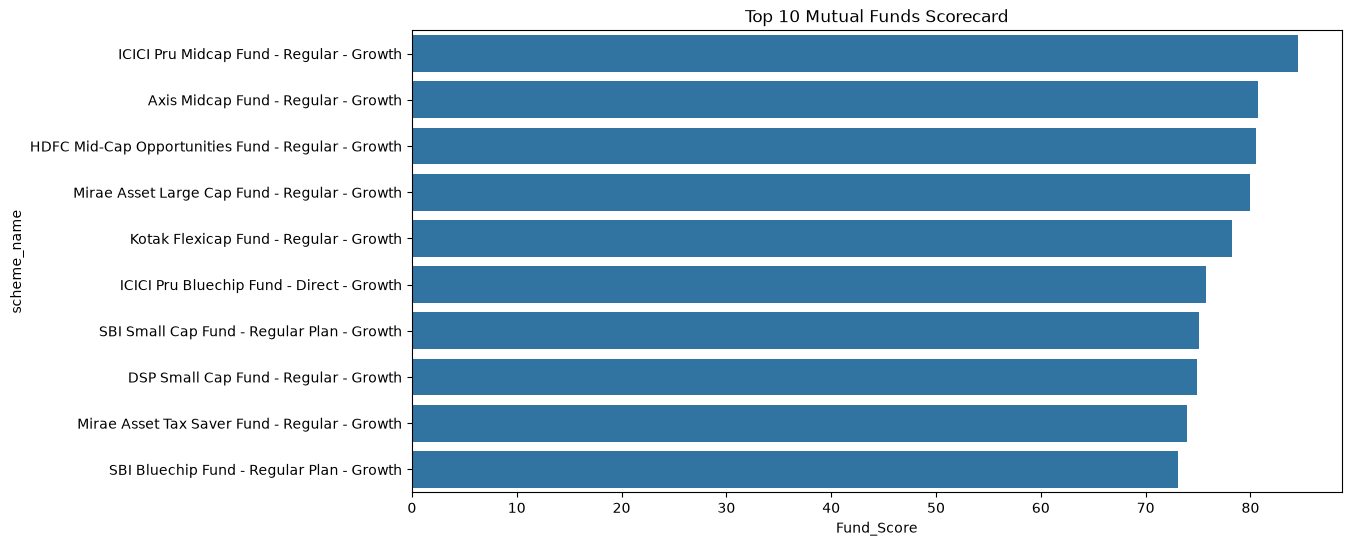

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

top10 = scorecard.head(10)

fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(

data=top10,

x="Fund_Score",

y="scheme_name",

ax=ax

)

ax.set_title(
    "Top 10 Mutual Funds Scorecard"
)

fig.savefig(
    "../reports/charts/fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

-----  Benchmark Comparison

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [46]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv")

benchmark = pd.read_csv("../data/processed/clean_10_benchmark_indices.csv")

scorecard = pd.read_csv("../data/processed/fund_scorecard.csv")

fund_master = pd.read_csv("../data/processed/clean_01_fund_master.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [47]:
top5 = scorecard.sort_values(
    "Fund_Score",
    ascending=False
).head(5)

top5_codes = top5["amfi_code"].tolist()

top5

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Alpha,Maximum_Drawdown,expense_ratio_pct,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,Drawdown_Score,Fund_Score
0,120505,ICICI Pru Midcap Fund - Regular - Growth,29.604659,31.777537,NaN,1.180101,0.292636,-18.188514,1.36,5.0,5.0,3.0,15.0,16.0,90.0,90.0,95.0,65.0,62.5,84.50
1,119094,Axis Midcap Fund - Regular - Growth,22.261065,35.111802,NaN,0.998231,0.260767,-20.960884,1.38,1.0,11.0,9.0,17.0,13.0,100.0,75.0,80.0,60.0,70.0,80.75
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,NaN,1.093699,0.271954,-16.217209,1.38,4.0,7.0,6.0,17.0,21.0,92.5,85.0,87.5,60.0,50.0,80.50
3,148567,Mirae Asset Large Cap Fund - Regular - Growth,20.360678,34.000916,NaN,1.448291,0.269838,-11.265729,1.46,2.0,1.0,7.0,23.0,33.0,97.5,100.0,85.0,45.0,20.0,80.00
4,120843,Kotak Flexicap Fund - Regular - Growth,26.657082,29.582770,NaN,1.306744,0.273305,-12.973968,1.45,7.0,2.0,5.0,22.0,28.0,85.0,97.5,90.0,47.5,32.5,78.25


In [48]:
top5_nav = nav[
    nav["amfi_code"].isin(top5_codes)
]

top5_nav = top5_nav.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

top5_nav.head()

,amfi_code,date,nav,scheme_name
0,100033,2022-01-03,107.3758,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
1,100033,2022-01-04,105.9447,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,100033,2022-01-05,105.4800,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,100033,2022-01-06,104.9350,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,100033,2022-01-07,104.3318,HDFC Mid-Cap Opportunities Fund - Regular - Gr...


In [49]:
latest = top5_nav["date"].max()

top5_nav = top5_nav[
    top5_nav["date"] >= latest-pd.DateOffset(years=3)
]

benchmark = benchmark[
    benchmark["date"] >= latest-pd.DateOffset(years=3)
]

In [50]:
benchmark = benchmark[
    benchmark["index_name"].isin(
        [
            "NIFTY50",
            "NIFTY100"
        ]
    )
]

In [51]:
top5_nav["normalized_nav"] = top5_nav.groupby(
    "scheme_name"
)["nav"].transform(
    lambda x: x/x.iloc[0]*100
)

In [52]:
benchmark["normalized_index"] = benchmark.groupby(
    "index_name"
)["close_value"].transform(
    lambda x: x/x.iloc[0]*100
)

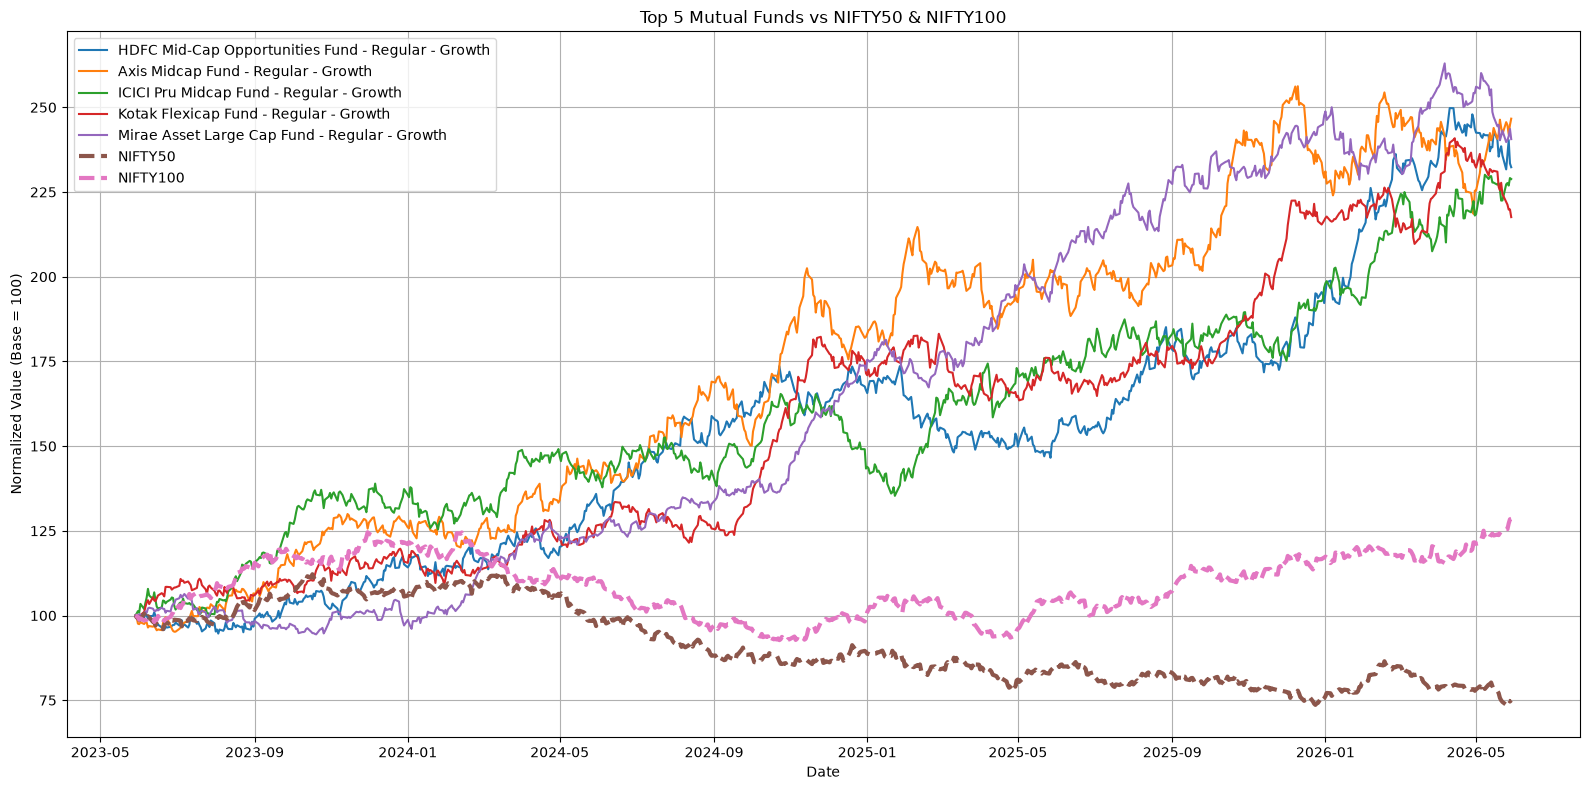

In [53]:
plt.figure(figsize=(16,8))

for scheme in top5_nav["scheme_name"].unique():

    df = top5_nav[
        top5_nav["scheme_name"]==scheme
    ]

    plt.plot(
        df["date"],
        df["normalized_nav"],
        label=scheme
    )

for idx in benchmark["index_name"].unique():

    df = benchmark[
        benchmark["index_name"]==idx
    ]

    plt.plot(
        df["date"],
        df["normalized_index"],
        linewidth=3,
        linestyle="--",
        label=idx
    )

plt.title("Top 5 Mutual Funds vs NIFTY50 & NIFTY100")

plt.xlabel("Date")

plt.ylabel("Normalized Value (Base = 100)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [54]:
benchmark100 = benchmark[
    benchmark["index_name"]=="NIFTY100"
].copy()

benchmark100["benchmark_return"] = benchmark100[
    "close_value"
].pct_change()

tracking=[]

for code in top5_codes:

    fund = nav[
        nav["amfi_code"]==code
    ].copy()

    fund["fund_return"] = fund["nav"].pct_change()

    merged = pd.merge(
        fund[
            ["date","fund_return"]
        ],
        benchmark100[
            ["date","benchmark_return"]
        ],
        on="date"
    ).dropna()

    tracking_error = (
        (
            merged["fund_return"]
            -
            merged["benchmark_return"]
        ).std()
    )*np.sqrt(252)

    scheme = fund_master.loc[
        fund_master["amfi_code"]==code,
        "scheme_name"
    ].values[0]

    tracking.append(
        [
            code,
            scheme,
            tracking_error
        ]
    )

In [55]:
tracking = pd.DataFrame(

    tracking,

    columns=[
        "amfi_code",
        "scheme_name",
        "Tracking_Error"
    ]

)

tracking

,amfi_code,scheme_name,Tracking_Error
0,120505,ICICI Pru Midcap Fund - Regular - Growth,0.232661
1,119094,Axis Midcap Fund - Regular - Growth,0.239774
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.224976
3,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.187974
4,120843,Kotak Flexicap Fund - Regular - Growth,0.206540


In [56]:
tracking.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)